Import delle librerie

In [19]:
import pandas as pd
import torch
from transformers import pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import json


Verifichiamo disponibilità del dispositivo

In [ ]:
# Verifica se il chip M2 (MPS) è disponibile
device = 0 if torch.backends.mps.is_available() else -1
print(f"Dispositivo in uso: {'Apple M2 (MPS)' if device == 0 else 'CPU'}")

Dispositivo in uso: Apple M2 (MPS)


Caricamento dati e modello

In [11]:
# Carica il test set
df_test = pd.read_csv("../data/test_set.csv")

# Estrai colonne dal dataset
texts = df_test["text"].tolist()
y_true = df_test["label"].tolist()

# Inizializza la pipeline di classificazione
classifier = pipeline(
    "text-classification", 
    model="../models/github_bert_finetuned", 
    device=device
)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 17241.45it/s]


Predizione sul test

In [12]:
# FORZIAMO L'USO DELLA CPU PER ESCLUDERE BUG DELLA GPU
device = -1

print("Ricaricamento modello su CPU...")

classifier = pipeline(
    "text-classification", 
    model="../models/github_bert_finetuned", 
    device=device
)

print("Inizio classificazione su CPU...")

y_pred_labels = []

for i in tqdm(range(0, len(texts), 32)):
    batch = texts[i:i+32]

    # Assicurati che i testi siano stringhe
    batch = [str(t) for t in batch]

    out = classifier(batch, truncation=True)

    y_pred_labels.extend([res['label'] for res in out])

print(f"Fatto! Totale predizioni: {len(y_pred_labels)}")

Ricaricamento modello su CPU...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 15052.94it/s]


Inizio classificazione su CPU...


100%|██████████| 438/438 [31:00<00:00,  4.25s/it]   

Fatto! Totale predizioni: 13994


Analisi dei risultati e metriche


--- REPORT FINALE (Dati Normalizzati) ---
              precision    recall  f1-score   support

         bug       0.89      0.92      0.91      6997
     feature       0.92      0.89      0.90      6997

    accuracy                           0.90     13994
   macro avg       0.91      0.90      0.90     13994
weighted avg       0.91      0.90      0.90     13994



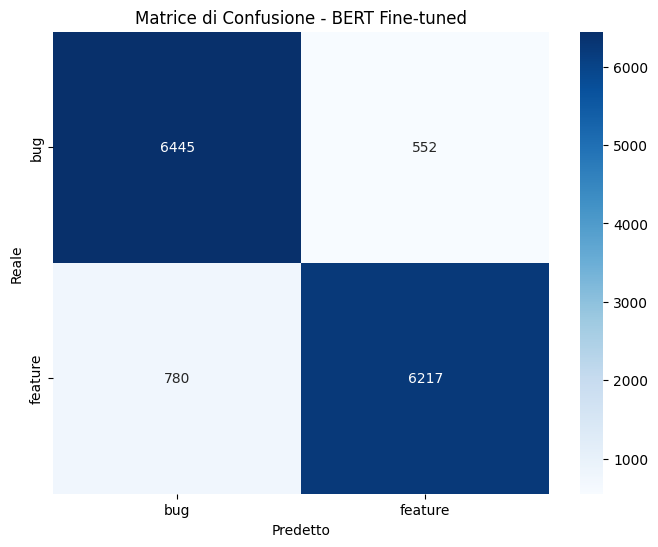

In [23]:
# 1. Normalizziamo y_true (le etichette reali del dataset)
y_true_norm = [1 if str(x).lower() == 'feature' else 0 for x in df_test['label']]

# 2. Normalizziamo y_pred (quello che ha predetto il modello)
y_pred_norm = []
for x in y_pred_labels:
    val = str(x).upper()
    if 'LABEL_1' in val or 'FEATURE' in val:
        y_pred_norm.append(1)
    else:
        y_pred_norm.append(0)

# 3. Stampiamo i risultati testuali
print("\n--- REPORT FINALE (Dati Normalizzati) ---")
print(classification_report(y_true_norm, y_pred_norm, target_names=['bug', 'feature']))

# 4. PLOT DELLA MATRICE DI CONFUSIONE
cm = confusion_matrix(y_true_norm, y_pred_norm)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['bug', 'feature'], 
            yticklabels=['bug', 'feature'])
plt.xlabel('Predetto')
plt.ylabel('Reale')
plt.title('Matrice di Confusione - BERT Fine-tuned')
plt.show()

# 5. Aggiorniamo il dataframe per la visualizzazione
df_test['pred_label_num'] = y_pred_norm
df_test['pred_label_name'] = ["feature" if p == 1 else "bug" for p in y_pred_norm]


Salvataggio Risultati

In [24]:
# 1. Calcolo delle metriche
# Usiamo average='binary' per ottenere i risultati relativi alla classe positiva (feature)
precision, recall, f1, _ = precision_recall_fscore_support(y_true_norm, y_pred_norm, average='binary')
acc = accuracy_score(y_true_norm, y_pred_norm)
cm = confusion_matrix(y_true_norm, y_pred_norm)

# 2. Creazione della struttura dati
results_dict = {
    "bert_finetuned": {
        "accuracy": float(acc),
        "precision": float(precision),
        "recall": float(recall),
        "f1_score": float(f1),
        "confusion_matrix": cm.tolist() 
    }
}

# 3. Salvataggio diretto nel file
file_path = "../results/metrics_bert.json"

with open(file_path, "w") as f:
    json.dump(results_dict, f, indent=4)

print(f"Risultati salvati correttamente")

Risultati salvati correttamente
